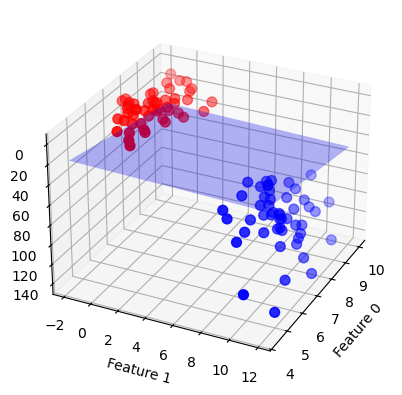

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs as mb
from sklearn.svm import LinearSVC as ls
X, Y = mb(n_samples=100, centers=2, random_state=8)
Y = Y % 2

lsvm = ls().fit(X, Y)
X_new = np.hstack([X, (X[:, 1:] ** 2)])
lsvm_3d = ls().fit(X_new, Y)
coef, intercept = lsvm_3d.coef_.ravel(), lsvm_3d.intercept_

figure = plt.figure()
ax = figure.add_subplot(111, projection='3d', elev=-152, azim=-26)


XX = np.linspace(X_new[:, 0].min() , X_new[:, 0].max() , 50)
YY = np.linspace(X_new[:, 1].min() , X_new[:, 1].max() , 50)
XX, YY = np.meshgrid(XX, YY)

ZZ = (-coef[0] * XX - coef[1] * YY - intercept) / coef[2]


ax.plot_surface(XX, YY, ZZ, alpha=0.3, color='b', linewidth=0, antialiased=True)

mask = Y == 0
ax.scatter(X_new[mask, 0], X_new[mask, 1], X_new[mask, 2], c='b', s=50)
ax.scatter(X_new[~mask, 0], X_new[~mask, 1], X_new[~mask, 2], c='r', s=50)

ax.set_xlabel("Feature 0")
ax.set_ylabel("Feature 1")
plt.show()
